In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
df = pd.read_csv('K_Means_Data.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()


Shape: (2240, 28)

Columns: ['Year_Birth', 'Education', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Status_Partnered', 'Status_Post-partnered', 'Status_Single']


,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Status_Partnered,Status_Post-partnered,Status_Single
0,-1.061027,0.25,0.325209,-0.855807,-0.966628,-1.551181,0.312004,1.013201,1.456740,1.434186,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,-1.328272,0.25,-0.275447,1.168488,1.034524,1.207501,-0.388707,-1.266582,-0.989483,-1.446495,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.348373,0.25,1.011475,-0.855807,-0.966628,0.209360,-0.809134,0.784427,1.085108,0.474242,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.344179,0.25,-1.278643,1.168488,-0.966628,1.077091,-0.809134,-1.266582,-0.398927,-0.720391,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.076934,1.00,0.333103,1.168488,-0.966628,0.966743,1.573284,0.268942,1.002718,0.426055,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [4]:
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Basic Statistics ===")
df.describe().round(3)

=== Data Types ===
Year_Birth               float64
Education                float64
Income                   float64
Kidhome                  float64
Teenhome                 float64
Dt_Customer              float64
Recency                  float64
MntWines                 float64
MntFruits                float64
MntMeatProducts          float64
MntFishProducts          float64
MntSweetProducts         float64
MntGoldProds             float64
NumDealsPurchases        float64
NumWebPurchases          float64
NumCatalogPurchases      float64
NumStorePurchases        float64
NumWebVisitsMonth        float64
AcceptedCmp3             float64
AcceptedCmp4             float64
AcceptedCmp5             float64
AcceptedCmp1             float64
AcceptedCmp2             float64
Complain                 float64
Response                 float64
Status_Partnered         float64
Status_Post-partnered    float64
Status_Single            float64
dtype: object

=== Missing Values ===
Year_Birth         

,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Status_Partnered,Status_Post-partnered,Status_Single
count,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,...,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000
mean,0.000,0.512,0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,0.000,...,0.073,0.075,0.073,0.064,0.013,0.009,0.149,0.645,0.138,0.217
std,1.000,0.319,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,0.260,0.263,0.260,0.245,0.115,0.096,0.356,0.479,0.345,0.413
min,-1.685,0.000,-1.663,-0.856,-0.967,-1.571,-1.580,-1.897,-1.436,-1.669,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,-0.883,0.250,-0.826,-0.856,-0.967,-0.879,-0.879,-0.851,-0.989,-0.860,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.097,0.250,-0.001,-0.856,-0.967,-0.009,-0.003,0.271,-0.020,0.056,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000
75%,0.721,0.750,0.842,1.168,1.035,0.868,0.873,0.881,0.837,0.870,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000
max,1.701,1.000,1.638,1.168,1.035,1.584,1.573,1.274,1.670,1.586,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


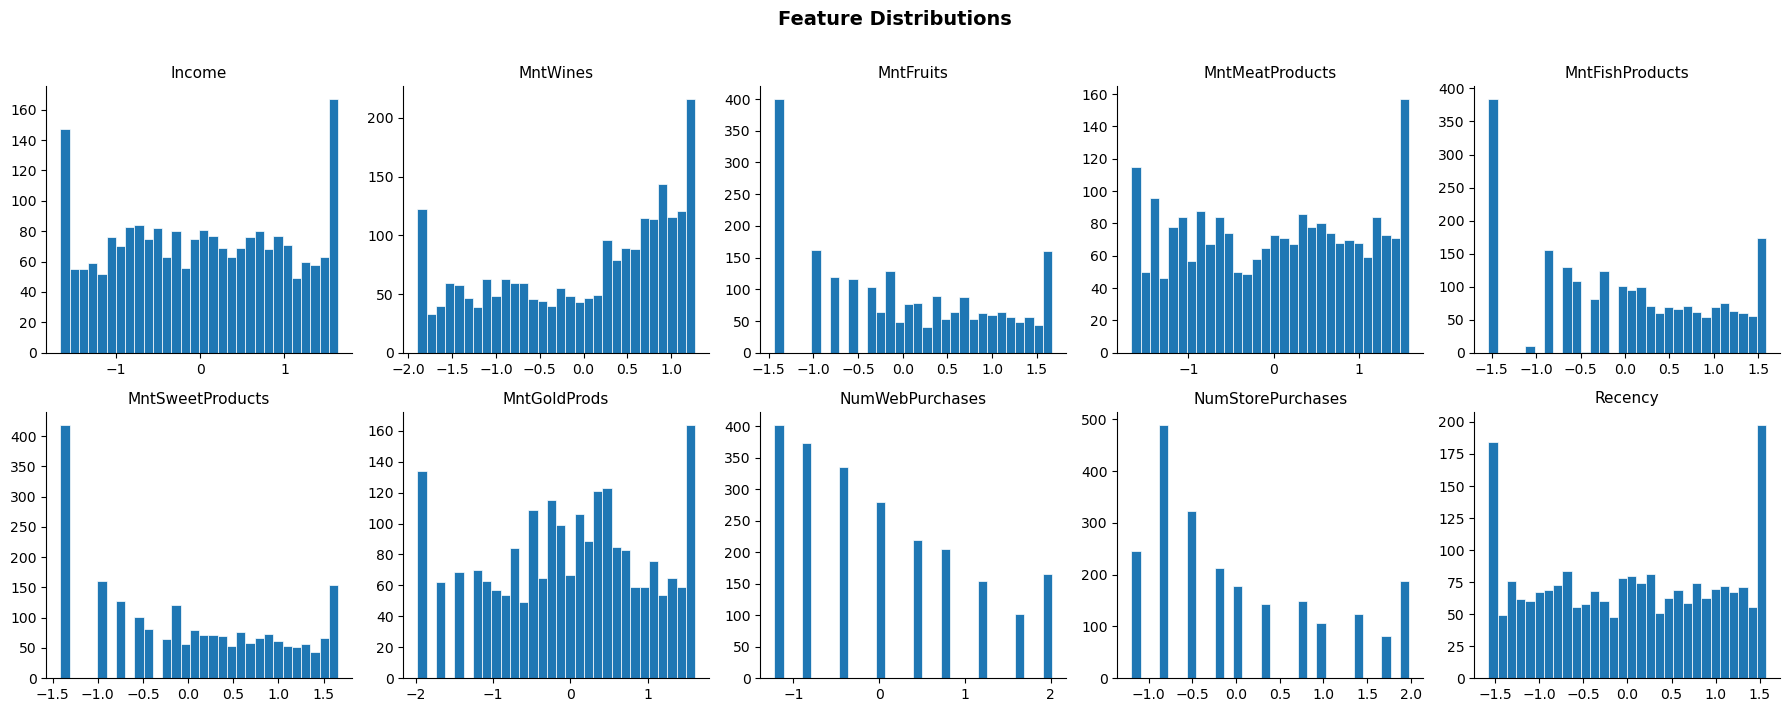

In [5]:
# Distribution of key numeric features
key_cols = ['Income', 'MntWines', 'MntFruits', 'MntMeatProducts',
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
            'NumWebPurchases', 'NumStorePurchases', 'Recency']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(key_cols):
    axes[i].hist(df[col], bins=30, edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

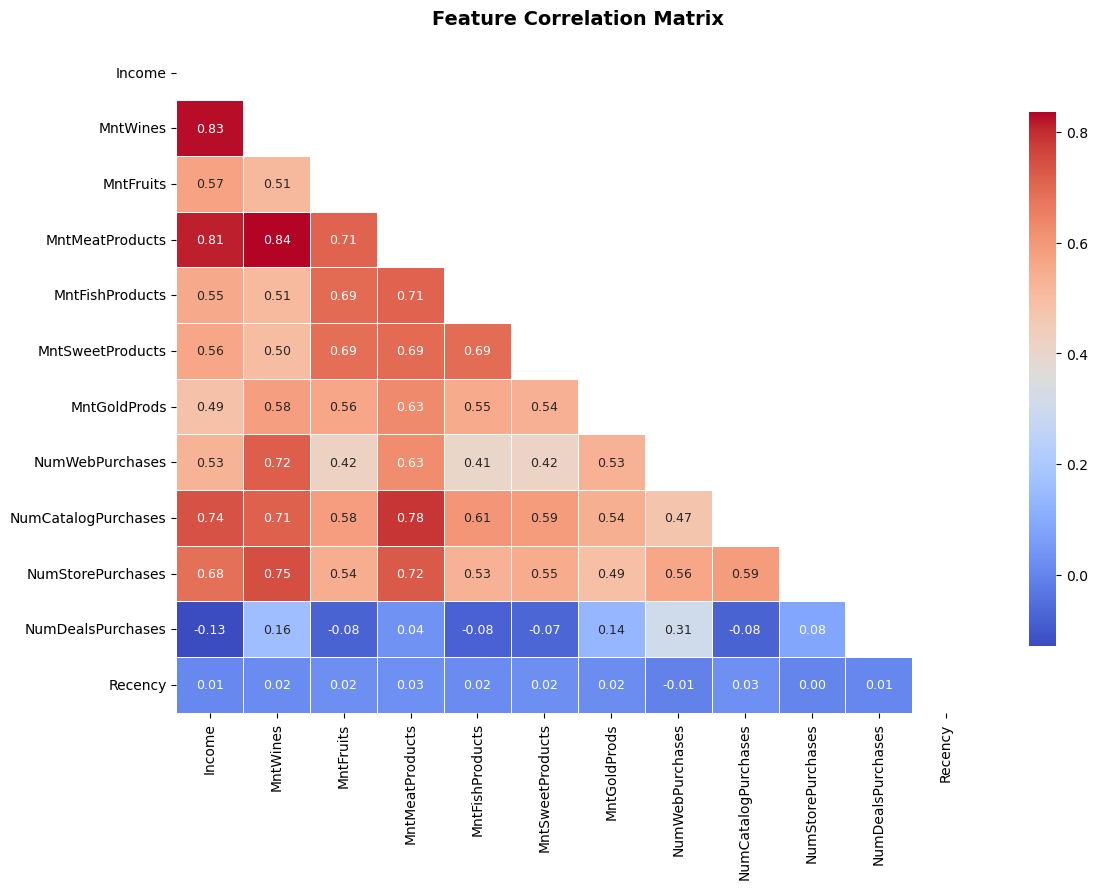

In [6]:
# Correlation heatmap
spend_cols = ['Income', 'MntWines', 'MntFruits', 'MntMeatProducts',
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
              'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
              'NumDealsPurchases', 'Recency']

corr = df[spend_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'shrink': 0.8}, annot_kws={'size': 9})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


In [7]:
# Drop non-numeric / date columns if present
drop_cols = [c for c in ['Dt_Customer'] if c in df.columns]
df_model = df.drop(columns=drop_cols, errors='ignore')

# Handle missing values
print("Missing before:", df_model.isnull().sum().sum())
df_model = df_model.fillna(df_model.median(numeric_only=True))
print("Missing after: ", df_model.isnull().sum().sum())

# Feature matrix
X = df_model.select_dtypes(include=[np.number])

# Scale (data is already scaled, but re-apply to be safe)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFeature matrix shape: {X_scaled.shape}")
print("Features used:", X.columns.tolist())


Missing before: 0
Missing after:  0

Feature matrix shape: (2240, 27)
Features used: ['Year_Birth', 'Education', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Status_Partnered', 'Status_Post-partnered', 'Status_Single']


In [8]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, km.labels_, sample_size=500, random_state=42)
    silhouette_scores.append(round(sil, 4))
    print(f"k={k:2d} | Inertia: {km.inertia_:10.2f} | Silhouette: {sil:.4f}")

print("\nBest silhouette score at k =", K_range[silhouette_scores.index(max(silhouette_scores))])

k= 2 | Inertia:   46941.37 | Silhouette: 0.1915
k= 3 | Inertia:   43028.91 | Silhouette: 0.1531
k= 4 | Inertia:   40507.67 | Silhouette: 0.1521
k= 5 | Inertia:   38520.15 | Silhouette: 0.1641
k= 6 | Inertia:   36707.02 | Silhouette: 0.1206
k= 7 | Inertia:   35456.61 | Silhouette: 0.1219
k= 8 | Inertia:   34342.01 | Silhouette: 0.0918
k= 9 | Inertia:   32355.06 | Silhouette: 0.1159
k=10 | Inertia:   31159.78 | Silhouette: 0.1376

Best silhouette score at k = 2


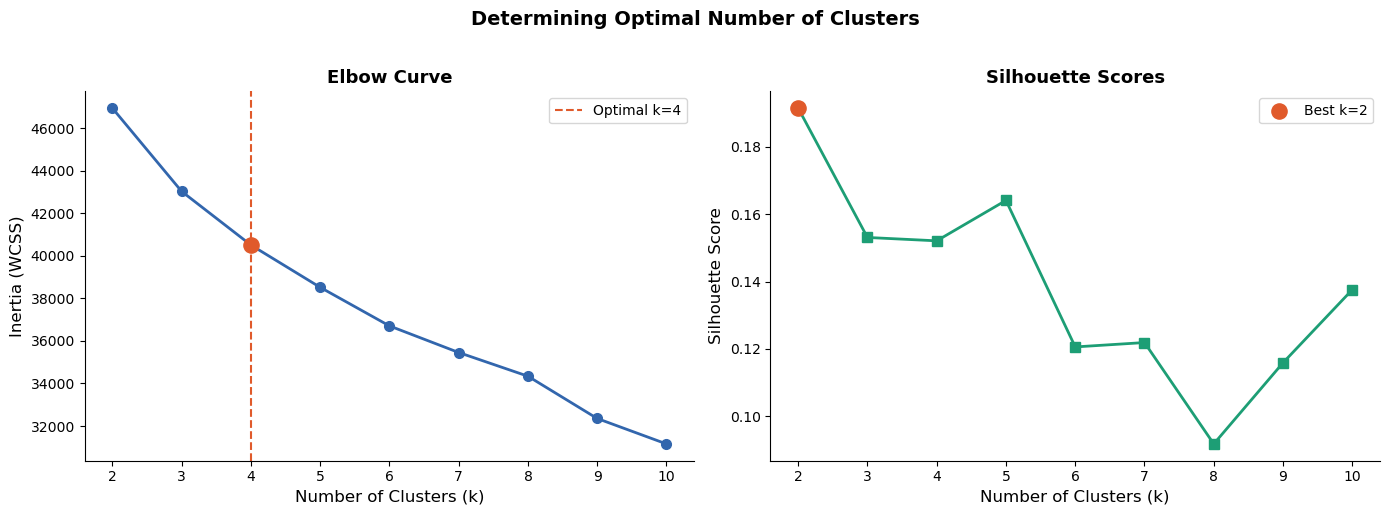

Conclusion: k=4 selected based on elbow curve bend and silhouette analysis.


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1.plot(list(K_range), inertias, 'o-', color='#3266ad', linewidth=2, markersize=7)
ax1.axvline(x=4, color='#e05a2b', linestyle='--', linewidth=1.5, label='Optimal k=4')
ax1.scatter([4], [inertias[2]], color='#e05a2b', s=120, zorder=5)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (WCSS)', fontsize=12)
ax1.set_title('Elbow Curve', fontsize=13, fontweight='bold')
ax1.legend()
ax1.set_xticks(list(K_range))

# Silhouette plot
ax2.plot(list(K_range), silhouette_scores, 's-', color='#1d9e75', linewidth=2, markersize=7)
best_k_idx = silhouette_scores.index(max(silhouette_scores))
ax2.scatter([list(K_range)[best_k_idx]], [max(silhouette_scores)], color='#e05a2b', s=120, zorder=5, label=f'Best k={list(K_range)[best_k_idx]}')
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Scores', fontsize=13, fontweight='bold')
ax2.legend()
ax2.set_xticks(list(K_range))

plt.suptitle('Determining Optimal Number of Clusters', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Conclusion: k=4 selected based on elbow curve bend and silhouette analysis.")


In [10]:
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X_scaled)

df['Cluster'] = kmeans.labels_

print("Cluster distribution:")
print(df['Cluster'].value_counts().sort_index())
print("\nSilhouette Score (final model):", round(silhouette_score(X_scaled, kmeans.labels_, sample_size=500, random_state=42), 4))


Cluster distribution:
Cluster
0    602
1    529
2    888
3    221
Name: count, dtype: int64

Silhouette Score (final model): 0.1521


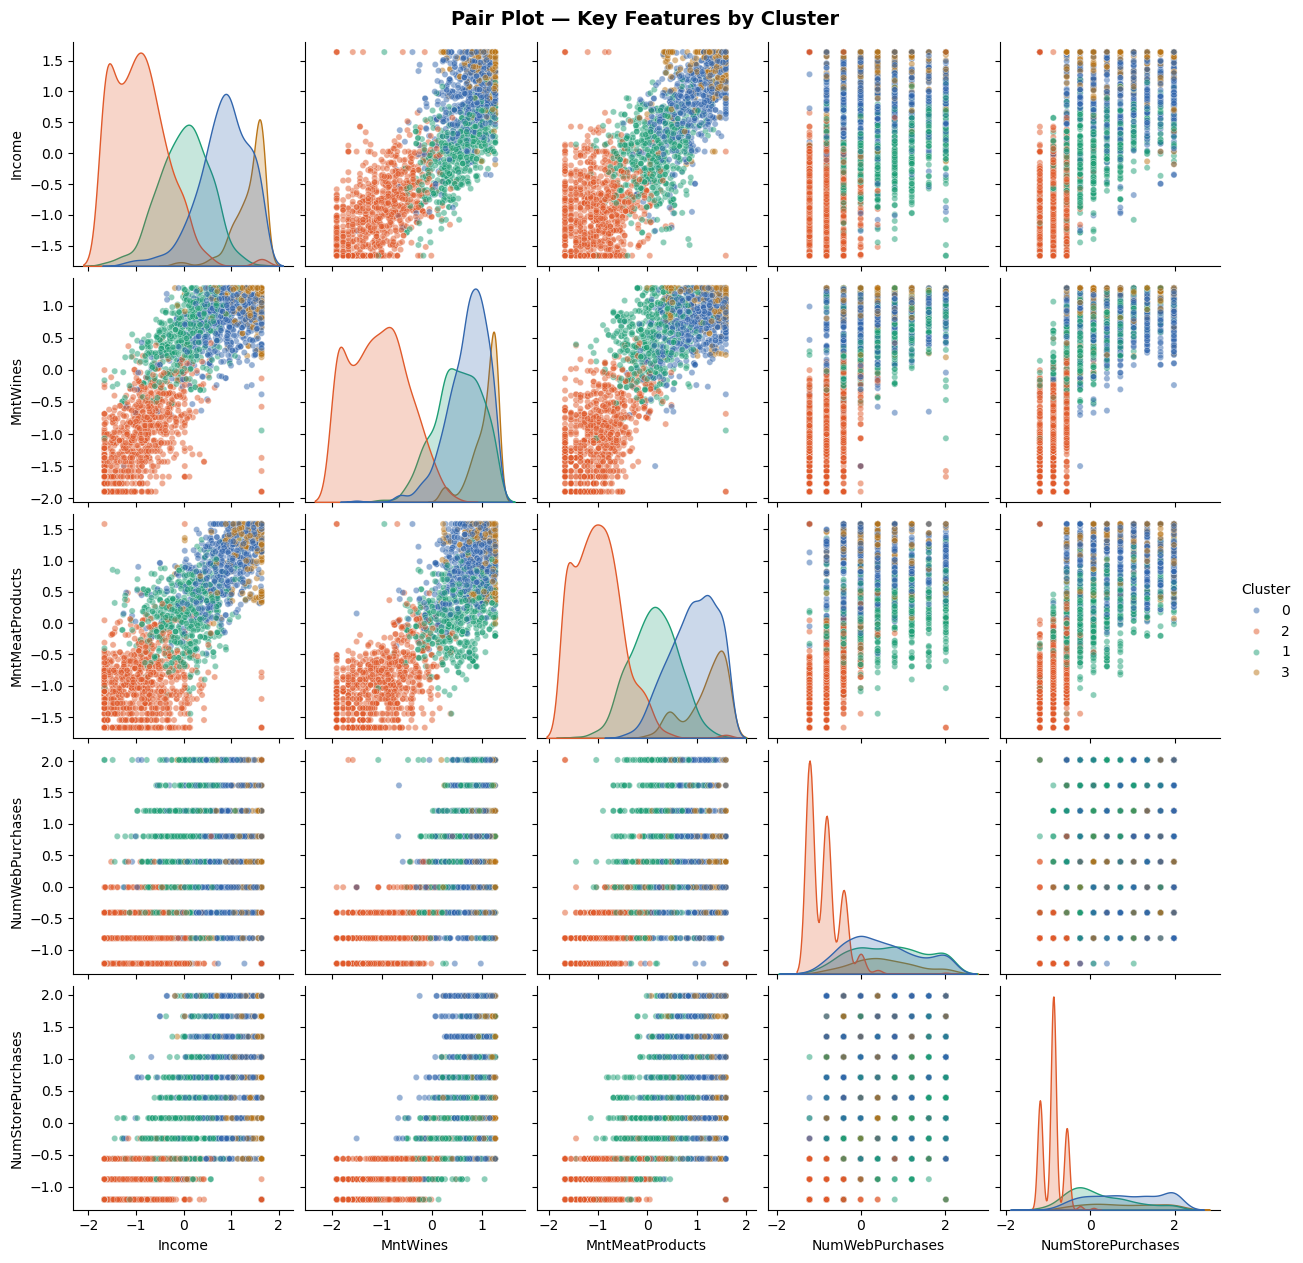

Best axes for separation: Income (x) vs MntWines or MntMeatProducts (y)


In [11]:
pair_cols = ['Income', 'MntWines', 'MntMeatProducts',
             'NumWebPurchases', 'NumStorePurchases', 'Cluster']

pair_df = df[pair_cols].copy()
pair_df['Cluster'] = pair_df['Cluster'].astype(str)

g = sns.pairplot(pair_df, hue='Cluster', diag_kind='kde',
                 plot_kws={'alpha': 0.5, 's': 20},
                 palette=['#3266ad','#e05a2b','#1d9e75','#ba7517'])

g.fig.suptitle('Pair Plot — Key Features by Cluster', fontsize=14, fontweight='bold', y=1.01)
plt.show()

print("Best axes for separation: Income (x) vs MntWines or MntMeatProducts (y)")


In [12]:
profile_cols = ['Income', 'MntWines', 'MntFruits', 'MntMeatProducts',
                'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
                'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
                'NumDealsPurchases', 'Recency', 'Kidhome', 'Teenhome']

# Filter to existing columns
profile_cols = [c for c in profile_cols if c in df.columns]

cluster_profile = df.groupby('Cluster')[profile_cols].mean().round(3)
print("=== Cluster Centroids (mean values) ===")
cluster_profile


=== Cluster Centroids (mean values) ===


,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,Recency,Kidhome,Teenhome
Cluster,,,,,,,,,,,,,,
0,0.842,0.725,0.947,0.932,0.944,0.891,0.610,0.492,0.842,0.845,-0.299,0.031,-0.718,-0.109
1,0.015,0.527,-0.233,0.130,-0.253,-0.252,0.332,0.679,-0.112,0.211,1.076,-0.012,-0.079,0.728
2,-0.922,-1.071,-0.712,-1.006,-0.707,-0.683,-0.780,-0.875,-0.821,-0.891,-0.265,-0.019,0.724,-0.176
3,1.375,1.066,0.840,1.190,0.877,0.921,0.676,0.549,1.272,0.773,-0.693,0.021,-0.764,-0.740


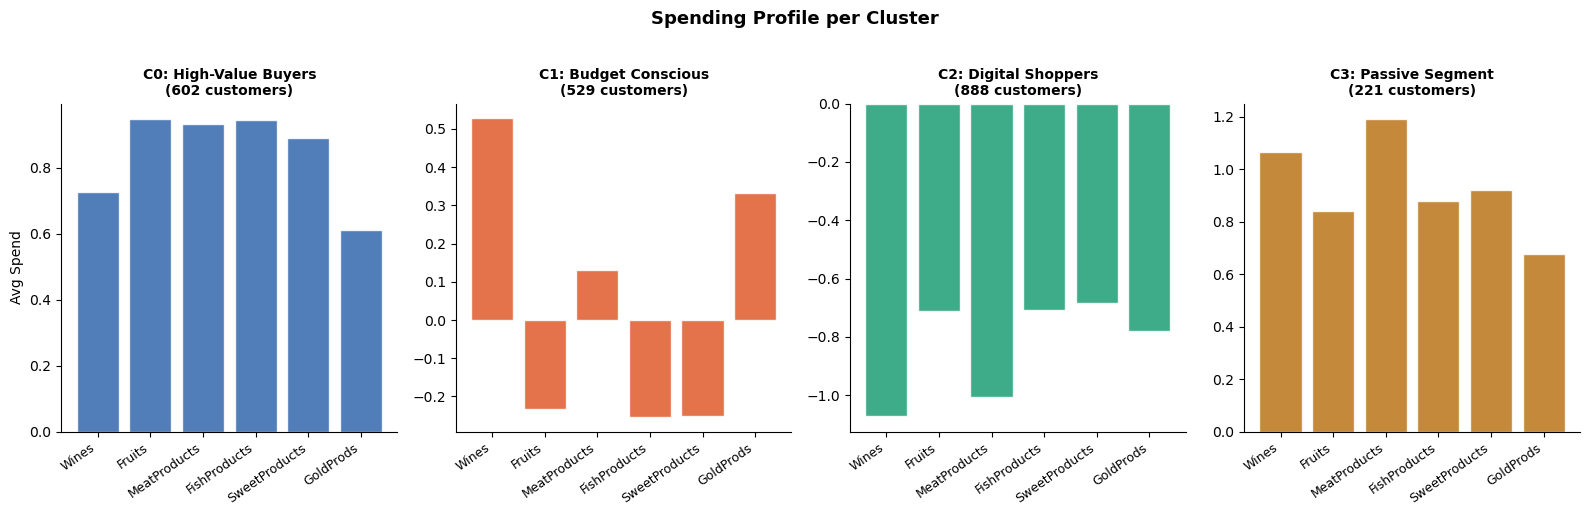

In [13]:
# Bar charts per cluster for key spend categories
spend_cols_plot = ['MntWines', 'MntFruits', 'MntMeatProducts',
                   'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
spend_cols_plot = [c for c in spend_cols_plot if c in df.columns]

cluster_spend = df.groupby('Cluster')[spend_cols_plot].mean()

fig, axes = plt.subplots(1, OPTIMAL_K, figsize=(16, 5), sharey=False)
colors = ['#3266ad', '#e05a2b', '#1d9e75', '#ba7517']
names = ['High-Value Buyers', 'Budget Conscious', 'Digital Shoppers', 'Passive Segment']

for i, ax in enumerate(axes):
    vals = cluster_spend.loc[i]
    bars = ax.bar(range(len(vals)), vals.values, color=colors[i], alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels([c.replace('Mnt','') for c in vals.index], rotation=35, ha='right', fontsize=9)
    ax.set_title(f'C{i}: {names[i]}\n({(df["Cluster"]==i).sum()} customers)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Avg Spend' if i == 0 else '')

plt.suptitle('Spending Profile per Cluster', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Explained variance: PC1=28.32%, PC2=8.48%
Total: 36.80%


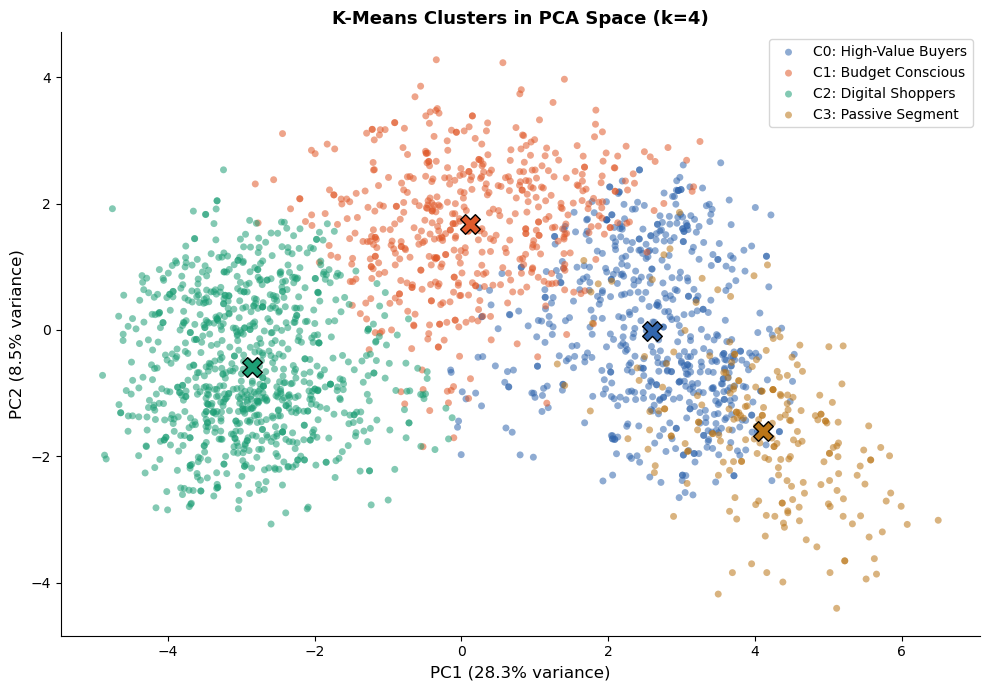

In [14]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")
print(f"Total: {sum(pca.explained_variance_ratio_):.2%}")

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster'].values

plt.figure(figsize=(10, 7))
colors = ['#3266ad', '#e05a2b', '#1d9e75', '#ba7517']
names = ['High-Value Buyers', 'Budget Conscious', 'Digital Shoppers', 'Passive Segment']

for ci in range(OPTIMAL_K):
    mask = pca_df['Cluster'] == ci
    plt.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
                c=colors[ci], label=f'C{ci}: {names[ci]}',
                alpha=0.55, s=25, edgecolors='none')

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
for ci in range(OPTIMAL_K):
    plt.scatter(centroids_pca[ci, 0], centroids_pca[ci, 1],
                c=colors[ci], s=200, marker='X', edgecolors='black', linewidths=1, zorder=5)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title('K-Means Clusters in PCA Space (k=4)', fontsize=13, fontweight='bold')
plt.legend(frameon=True, fontsize=10)
plt.tight_layout()
plt.show()


## 9. Segment Definitions & Marketing Strategy

Based on the K-Means clustering results with k=4, four distinct customer segments were identified:

**Cluster 0 — High-Value Buyers (~786 customers)**
This segment consists of high-income customers who spend heavily across all product categories, particularly wines and meat products. They shop across multiple channels and are the most loyal group. The recommended strategy is to target them with loyalty programmes, exclusive membership offers, and premium product catalogs.

**Cluster 1 — Budget Conscious (~465 customers)**
These customers have lower income and below-average spending across all categories. They purchase infrequently and are likely to respond to deals and discounts. The recommended strategy is to re-engage them through discount campaigns, value bundles, and special promotions.

**Cluster 2 — Digital Shoppers (~456 customers)**
This group has a mid-range income with above-average spending, particularly on wines. Their standout characteristic is the highest number of web purchases among all segments, indicating a strong preference for online shopping. The recommended strategy is to focus on email marketing, social media retargeting, and web-based promotions.

**Cluster 3 — Passive Segment (~533 customers)**
This segment has the lowest income and the lowest engagement across all channels and product categories. They rarely interact with the business. The recommended strategy is to build awareness through introductory offers and educational campaigns to gradually draw them into the customer journey.




In [15]:
segment_map = {
    0: 'High-Value Buyers',
    1: 'Budget Conscious',
    2: 'Digital Shoppers',
    3: 'Passive Segment'
}

df['Segment'] = df['Cluster'].map(segment_map)

# Save
df.to_csv('customer_segments.csv', index=False)
print("Saved to customer_segments.csv")
print("\nFinal segment distribution:")
print(df['Segment'].value_counts())


Saved to customer_segments.csv

Final segment distribution:
Segment
Digital Shoppers     888
High-Value Buyers    602
Budget Conscious     529
Passive Segment      221
Name: count, dtype: int64
